# EDA - Exploratórna Analýza Dát

Tento notebook obsahuje detailný prieskum dát potrebný na pochopenie:
- Štruktúry a kvality dát
- Rozdelenia fraud prípadov
- Vzťahov medzi premennými
- Anomálií a chýb v dátach

Na základe zistení sa nastaví proces data preprocessingu.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path
import pyarrow.parquet as pq
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')


# Nastavenie štýlu grafov
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# =============================================================================
# 1. NAČÍTANIE DÁTOVÝCH ZDROJOV
# =============================================================================
# Načítavame tri hlavné tabuľky:
# - cards: informácie o kartách
# - transactions: jednotlivé transakcie
# - users: informácie o používateľoch

root = Path.cwd().parent
data_dir = root / "data" / "raw"

cards = pq.read_table(data_dir / "cards.pq").to_pandas()
transactions = pq.read_table(data_dir / "transactions.pq").to_pandas()
users = pq.read_table(data_dir / "users.pq").to_pandas()

## Fáza 1: Základné Informácie o Vstupných Dátach

In [4]:
# =============================================================================
# 2. DÁTOVÉ TYPY A PRVÝ POHĽAD NA DÁTA
# =============================================================================

print("DÁTOVÉ TYPY - TRANSAKCIE\n")
print(transactions.dtypes)

print("\n\n--- Prvých 5 transakcií ---")
display(transactions.head())

print("\n\nDÁTOVÉ TYPY - POUŽÍVATELIA\n")
print(users.dtypes)

print("\n\n--- Prvých 5 používateľov ---")
display(users.head())

print("\n\nDÁTOVÉ TYPY - KARTY\n")
print(cards.dtypes)

print("\n\n--- Prvých 5 kariet ---")
display(cards.head())

DÁTOVÉ TYPY - TRANSAKCIE

User                int64
Card                int64
Year                int64
Month               int64
Day                 int64
Time                  str
Amount                str
Use Chip              str
Merchant Name       int64
Merchant City         str
Merchant State        str
Zip               float64
MCC                 int64
Errors?               str
Is Fraud?             str
dtype: object


--- Prvých 5 transakcií ---


,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC,Errors?,Is Fraud?
0,0,0,2018,1,2,06:28,$130.95,Chip Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,No
1,0,0,2018,1,5,06:02,$129.34,Chip Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,No
2,0,0,2018,1,5,17:56,$8.54,Online Transaction,6455213054093379528,ONLINE,NaN,NaN,5815,NaN,No
3,0,0,2018,1,6,06:23,$115.71,Chip Transaction,4722913068560264812,Alhambra,CA,91801.0,5411,NaN,No
4,0,0,2018,1,11,06:02,$107.50,Chip Transaction,2027553650310142703,Mira Loma,CA,91752.0,5541,NaN,No




DÁTOVÉ TYPY - POUŽÍVATELIA

User                             int64
Person                             str
Current Age                      int64
Retirement Age                   int64
Birth Year                       int64
Birth Month                      int64
Gender                             str
Address                            str
Apartment                      float64
City                               str
State                              str
Zipcode                          int64
Latitude                       float64
Longitude                      float64
Per Capita Income - Zipcode        str
Yearly Income - Person             str
Total Debt                         str
FICO Score                       int64
Num Credit Cards                 int64
dtype: object


--- Prvých 5 používateľov ---


,User,Person,Current Age,Retirement Age,Birth Year,Birth Month,Gender,Address,Apartment,City,State,Zipcode,Latitude,Longitude,Per Capita Income - Zipcode,Yearly Income - Person,Total Debt,FICO Score,Num Credit Cards
0,0,Hazel Robinson,53,66,1966,11,Female,462 Rose Lane,NaN,La Verne,CA,91750,34.15,-117.76,$29278,$59696,$127613,787,5
1,1,Sasha Sadr,53,68,1966,12,Female,3606 Federal Boulevard,NaN,Little Neck,NY,11363,40.76,-73.74,$37891,$77254,$191349,701,5
2,2,Saanvi Lee,81,67,1938,11,Female,766 Third Drive,NaN,West Covina,CA,91792,34.02,-117.89,$22681,$33483,$196,698,5
3,3,Everlee Clark,63,63,1957,1,Female,3 Madison Street,NaN,New York,NY,10069,40.71,-73.99,$163145,$249925,$202328,722,4
4,4,Kyle Peterson,43,70,1976,9,Male,9620 Valley Stream Drive,NaN,San Francisco,CA,94117,37.76,-122.44,$53797,$109687,$183855,675,1




DÁTOVÉ TYPY - KARTY

User                     int64
CARD INDEX               int64
Card Brand                 str
Card Type                  str
Card Number              int64
Expires                    str
CVV                      int64
Has Chip                   str
Cards Issued             int64
Credit Limit               str
Acct Open Date             str
Year PIN last Changed    int64
Card on Dark Web           str
dtype: object


--- Prvých 5 kariet ---


,User,CARD INDEX,Card Brand,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,1,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,0,2,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,0,3,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,0,4,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


In [5]:

# =============================================================================
# 3. ROZMERY A ŠTRUKTÚRA DATASETOV
# =============================================================================

print("ROZMERY DATASETOV")
print("=" * 60)
print(f"Transakcie:    {transactions.shape[0]:>10} riadkov, {transactions.shape[1]:>3} stĺpcov")
print(f"Používatelia:  {users.shape[0]:>10} riadkov, {users.shape[1]:>3} stĺpcov")
print(f"Karty:         {cards.shape[0]:>10} riadkov, {cards.shape[1]:>3} stĺpcov")
print("=" * 60)



ROZMERY DATASETOV
Transakcie:       3782053 riadkov,  15 stĺpcov
Používatelia:        2000 riadkov,  19 stĺpcov
Karty:               6146 riadkov,  13 stĺpcov


## Fáza 2: Spájanie Dát

In [3]:
# Spojíme vstupné tabuľky do jedného datasetu, ktorý bude obsahovat informácie na úrovni transakcií.

# Kontrola kľúčových polí
print("\n--- Unikátnosť kľúčových polí ---")
print(f"Unikátni používatelia:    {users['User'].nunique():>5} z {len(users):>5}")
print(f"Unikátne karty (index):   {cards['CARD INDEX'].nunique():>5} z {len(cards):>5}")
print(f"Unikátne karty v transc.: {transactions['Card'].nunique():>5} z {len(transactions):>5}")

#  UPOZORNENIE: Je len 9 unikátnych CARD INDEX! To znamená, že tieto 9 hodnôt sa opakujú pre rôznych používateľov. Pri merge bude potrebné použiť kombináciu 'CARD INDEX' a 'User' ako kľúč, nie len 'CARD INDEX'.

print("\nSPÁJANIE TABULIEK...")
print("Spájame: Transakcie + Používatelia + Karty")

data = (
    transactions
    .merge(users, on='User', how='left')
    .merge(cards,
           left_on=['User', 'Card'],
           right_on=['User', 'CARD INDEX'],
           how='left')
).drop(columns=['CARD INDEX'])  # Po merge už nepotrebujeme tento stĺpec

print("Spájanie hotové!")
print(f"   Výsledný dataset: {data.shape[0]} riadkov, {data.shape[1]} stĺpcov")

print("\n\nDÁTOVÉ TYPY stĺpcov v zjednotenom datasete\n")
print(data.dtypes)

print("\nPrvých 5 riadkov zjednotených dát:")
display(data.head())



--- Unikátnosť kľúčových polí ---
Unikátni používatelia:     2000 z  2000
Unikátne karty (index):       9 z  6146
Unikátne karty v transc.:     9 z 3782053

SPÁJANIE TABULIEK...
Spájame: Transakcie + Používatelia + Karty
Spájanie hotové!
   Výsledný dataset: 3782053 riadkov, 44 stĺpcov


DÁTOVÉ TYPY stĺpcov v zjednotenom datasete

User                             int64
Card                             int64
Year                             int64
Month                            int64
Day                              int64
Time                               str
Amount                             str
Use Chip                           str
Merchant Name                    int64
Merchant City                      str
Merchant State                     str
Zip                            float64
MCC                              int64
Errors?                            str
Is Fraud?                          str
Person                             str
Current Age                      int64
Ret

,User,Card,Year,Month,Day,Time,Amount,Use Chip,Merchant Name,Merchant City,...,Card Type,Card Number,Expires,CVV,Has Chip,Cards Issued,Credit Limit,Acct Open Date,Year PIN last Changed,Card on Dark Web
0,0,0,2018,1,2,06:28,$130.95,Chip Transaction,5817218446178736267,La Verne,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,0,0,2018,1,5,06:02,$129.34,Chip Transaction,-727612092139916043,Monterey Park,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
2,0,0,2018,1,5,17:56,$8.54,Online Transaction,6455213054093379528,ONLINE,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
3,0,0,2018,1,6,06:23,$115.71,Chip Transaction,4722913068560264812,Alhambra,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
4,0,0,2018,1,11,06:02,$107.50,Chip Transaction,2027553650310142703,Mira Loma,...,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No


## Fáza 3: Oboznámenie s Dátami

### Data cleaning necessary for further analysis

In [ ]:

# drop clearly useless columns
data.drop(columns=['Person', 'Card', 'CVV', "Birth Month", "Birth Year" ], inplace=True)

data.rename(columns={
    'Is Fraud?': 'Fraud',
    "User": "User ID",
    "Card Number": "Card ID",
    "MCC": "Merchant Category Code",
    "Zip": "Merchant Zip",
    "Zipcode": "User Zip",
    "Year" : "Transaction Year",
    "Month" : "Transaction Month",
    "Day" : "Transaction DayOfMonth",
    "Time": "Transaction Time",
    "Amount": "Transaction Amount",
    "Errors?": "Transaction Error", #can be multiple errors in one transaction, so we will have to break this column into multiple boolean columns later
    "Use Chip": "Transaction Type",
    "Current Age": "User Age",
    "Retirement Age": "User Retirement Age",
    "Gender": "User Gender",
    "Address": "User Address",
    "Apartment": "User Apartment Number",
    "City": "User City",
    "State": "User State",
    "Latitude": "User Latitude",
    "Longitude": "User Longitude",
    "Per Capita Income - Zipcode": "User Zipcode - Per Capita Income",
    "Yearly Income - Person": "User Yearly Income",
    "Total Debt": "User Total Debt",
    "FICO Score": "User FICO Score",
    "Num Credit Cards": "User Number of Credit Cards",
    "Expires": "Card Expiration Date",
    "Acct Open Date": "Account Open Date",
}, inplace=True)

data["Transaction Date"] = pd.to_datetime(
    dict(
        year=data["Transaction Year"],
        month=data["Transaction Month"],
        day=data["Transaction DayOfMonth"]
    ),
    errors="coerce"
)

time = pd.to_datetime(data["Transaction Time"], format="%H:%M")

data["Transaction Time"] = (
    data["Transaction Date"]
    + pd.to_timedelta(time.dt.hour, unit="h")
    + pd.to_timedelta(time.dt.minute, unit="m")
)

data.drop(columns=["Transaction Year", "Transaction Month", "Transaction DayOfMonth", "Transaction Time", "Transaction Date"], inplace=True)

cols_bool = ['Fraud', 'Has Chip', 'Card on Dark Web']

data[cols_bool] = (
    data[cols_bool]
    .apply(lambda col: col.astype(str).str.strip().str.lower())
    .replace({'yes': True, 'no': False})
)

cols_month_year = ['Card Expiration Date', 'Account Open Date']

data[cols_month_year] = (
    data[cols_month_year]
    .apply(lambda col: pd.to_datetime(col, format="%m/%Y") + pd.offsets.MonthEnd(0))
)

cols_financial = ['Transaction Amount', 'User Zipcode - Per Capita Income', "User Yearly Income", "User Total Debt", "Credit Limit"]

data[cols_financial] = (
    data[cols_financial]
    .replace(r'[^0-9\.-]', '', regex=True)
    .astype(float)
)

cols_to_str = ['User ID', 'Card ID', 'Merchant Name',  "Merchant Zip", "Merchant Category Code", "User Zip", "User Apartment Number"]

data[cols_to_str] = (
    data[cols_to_str]
    .apply(lambda col: col.round(0).astype(str).str.strip())
)

data.to_csv("data/processed/processed_data.csv", index=False)

print("\nPrvých 5 riadkov očistených dát:")
display(data.head())


Prvých 5 riadkov očistených dát:


,User ID,Transaction Amount,Transaction Type,Merchant Name,Merchant City,Merchant State,Merchant Zip,Merchant Category Code,Transaction Error,Fraud,...,Card ID,Card Expiration Date,Has Chip,Cards Issued,Credit Limit,Account Open Date,Year PIN last Changed,Card on Dark Web,Transaction Date,Transaction Time
0,0,130.95,Chip Transaction,5817218446178736267,La Verne,CA,91750.0,5912,NaN,False,...,4344676511950444,2022-12-31,True,2,24295.0,2002-09-30,2008,False,2018-01-02,2018-01-02 06:28:00
1,0,129.34,Chip Transaction,-727612092139916043,Monterey Park,CA,91754.0,5411,NaN,False,...,4344676511950444,2022-12-31,True,2,24295.0,2002-09-30,2008,False,2018-01-05,2018-01-05 06:02:00
2,0,8.54,Online Transaction,6455213054093379528,ONLINE,NaN,NaN,5815,NaN,False,...,4344676511950444,2022-12-31,True,2,24295.0,2002-09-30,2008,False,2018-01-05,2018-01-05 17:56:00
3,0,115.71,Chip Transaction,4722913068560264812,Alhambra,CA,91801.0,5411,NaN,False,...,4344676511950444,2022-12-31,True,2,24295.0,2002-09-30,2008,False,2018-01-06,2018-01-06 06:23:00
4,0,107.50,Chip Transaction,2027553650310142703,Mira Loma,CA,91752.0,5541,NaN,False,...,4344676511950444,2022-12-31,True,2,24295.0,2002-09-30,2008,False,2018-01-11,2018-01-11 06:02:00


## Train/Test split

## Feature engineering

In [ ]:
# date features
data["Transaction DayofWeek"] = data["Transaction Time"].dt.dayofweek

# time features
# minutes of day 
data["MinuteOfDay"] = (
    data["Transaction Time"].dt.hour * 60
    + data["Transaction Time"].dt.minute
)

# cyclic encoding
data["MinuteOfDay_Sin"] = np.sin(
    2 * np.pi * data["MinuteOfDay"] / 1440
)

data["MinuteOfDay_Cos"] = np.cos(
    2 * np.pi * data["MinuteOfDay"] / 1440
)

data.drop(columns=["MinuteOfDay"], inplace=True)

#

## Further cleaning

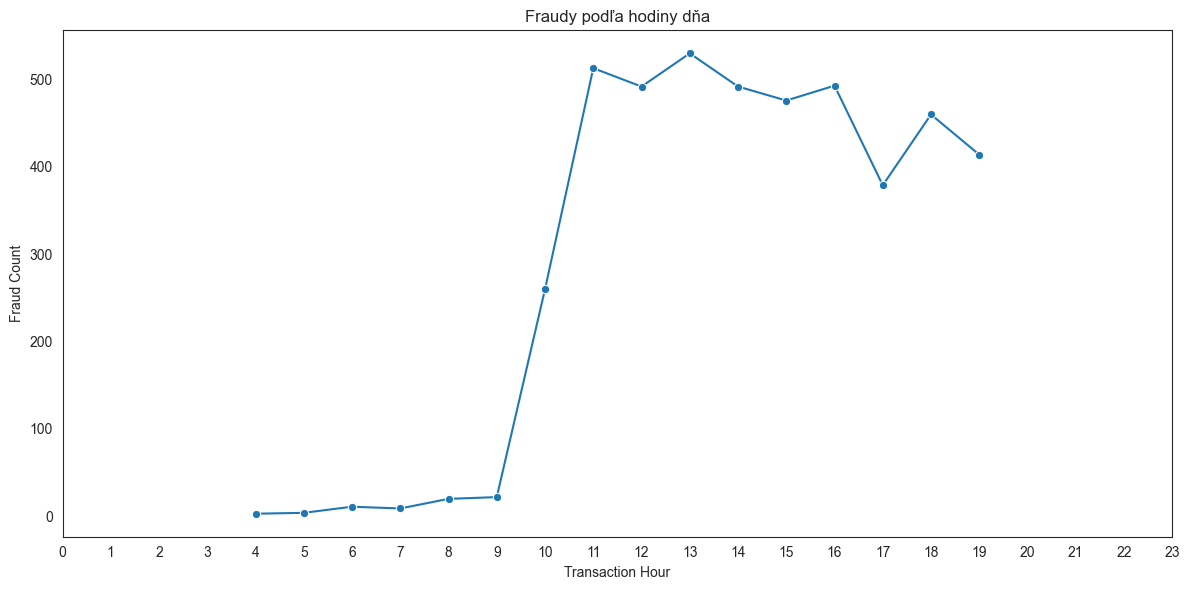

In [ ]:
data_hour_plot = data.copy()

data_hour_plot["Transaction Hour"] = data_hour_plot["Transaction Time"].dt.hour

fraud_by_hour = (
    data_hour_plot[data_hour_plot["Fraud"]]
    .groupby("Transaction Hour")
    .size()
    .reset_index(name="Fraud Count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=fraud_by_hour,
    x="Transaction Hour",
    y="Fraud Count",
    marker="o"
)

plt.xticks(range(24))
plt.title("Fraudy podľa hodiny dňa")

plt.tight_layout()
plt.show()

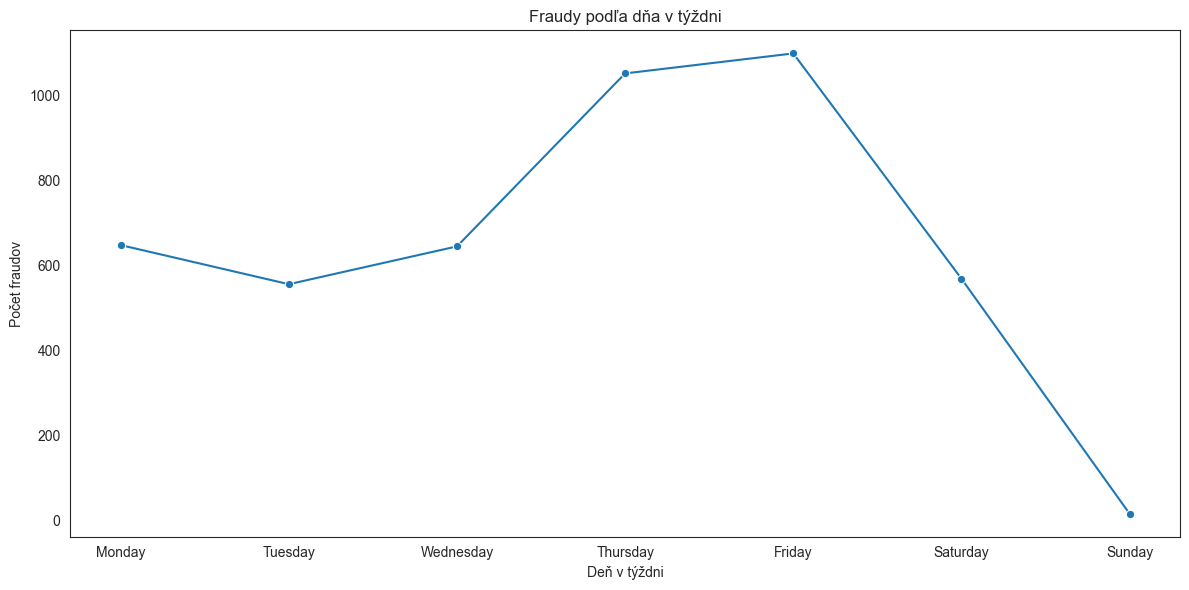

In [28]:
label_map = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

fraud_by_dayofweek = (
    data[data["Fraud"]]
    .groupby("Transaction DayofWeek")
    .size()
    .reset_index(name="Fraud Count")
)

plt.figure(figsize=(12, 6))

ax = sns.lineplot(
    data=fraud_by_dayofweek,
    x="Transaction DayofWeek",
    y="Fraud Count",
    marker="o"
)

# x-axis labels (ONLY visualization layer)
ax.set_xticks(range(7))
ax.set_xticklabels([label_map[i] for i in range(7)])

plt.title("Fraudy podľa dňa v týždni")
plt.xlabel("Deň v týždni")
plt.ylabel("Počet fraudov")

plt.tight_layout()
plt.show()

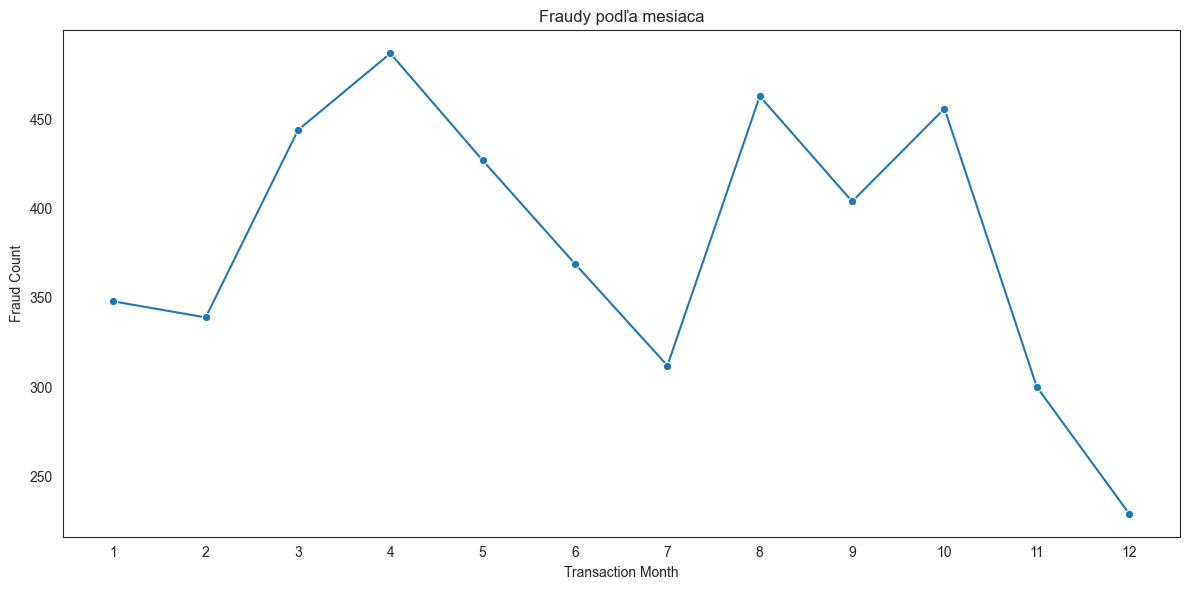

In [ ]:


fraud_by_hour = (
    data[data["Fraud"]]
    .groupby("Transaction Month")
    .size()
    .reset_index(name="Fraud Count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=fraud_by_hour,
    x="Transaction Month",
    y="Fraud Count",
    marker="o"
)

plt.xticks(range(1, 13))
plt.title("Fraudy podľa mesiaca")

plt.tight_layout()
plt.show()

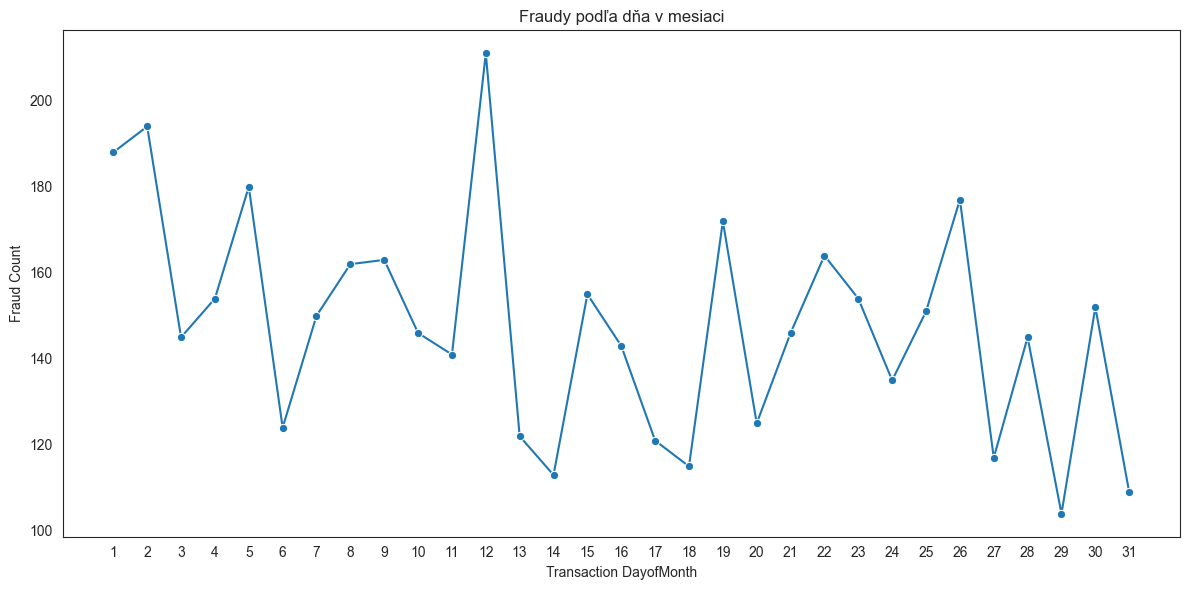

In [36]:
fraud_by_hour = (
    data[data["Fraud"]]
    .groupby("Transaction DayofMonth")
    .size()
    .reset_index(name="Fraud Count")
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=fraud_by_hour,
    x="Transaction DayofMonth",
    y="Fraud Count",
    marker="o"
)

plt.xticks(range(1, 32))
plt.title("Fraudy podľa dňa v mesiaci")

plt.tight_layout()
plt.show()

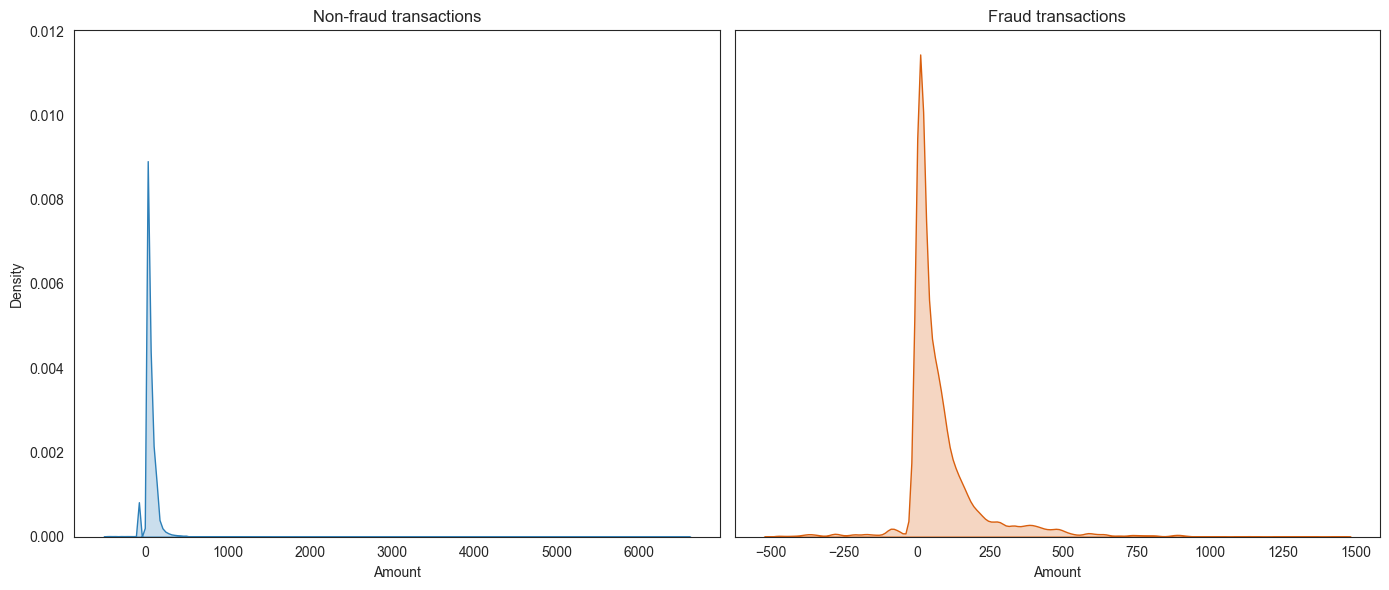

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Non-fraud
sns.kdeplot(
    data=data[data["Fraud"] == 0]["Amount"].dropna(),
    fill=True,
    bw_adjust=0.5,
    color="#2c7fb8",
    ax=axes[0]
)

axes[0].set_title("Non-fraud transactions")
axes[0].set_xlabel("Amount")
axes[0].set_ylabel("Density")

# Fraud
sns.kdeplot(
    data=data[data["Fraud"] == 1]["Amount"].dropna(),
    fill=True,
    bw_adjust=0.5,
    color="#d95f0e",
    ax=axes[1]
)

axes[1].set_title("Fraud transactions")
axes[1].set_xlabel("Amount")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

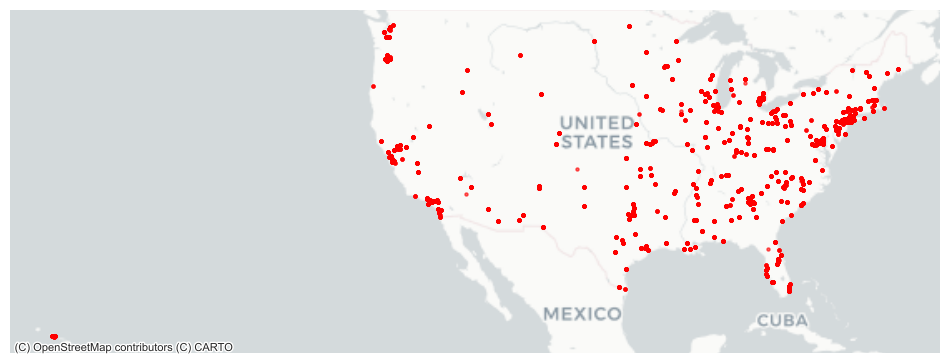

In [20]:

import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx

# filter frauds
fraud_data = data[data["Fraud"] == True].dropna(subset=["User Latitude", "User Longitude"])

# GeoDataFrame
gdf = gpd.GeoDataFrame(
    fraud_data,
    geometry=gpd.points_from_xy(fraud_data["User Longitude"], fraud_data["User Latitude"]),
    crs="EPSG:4326"
)

# transform to Web Mercator (required for tiles)
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 8))

# plot points
gdf.plot(
    ax=ax,
    color="red",
    markersize=5,
    alpha=0.6
)


ctx.add_basemap(ax,source=ctx.providers.CartoDB.Positron)

ax.set_axis_off()

plt.show()

#počet fraudov vs čas 
#počet fraudoch vs day of week
#počet fraudov vs vek užívatela
geografická mape fraud transakcií cez geopandas

### Základné štatistiky

#### Numerické premenné

In [27]:
print("NUMERICKÉ PREMENNÉ - ŠTATISTIKA")
print("=" * 80)

numeric_cols = data.select_dtypes(include=[np.number]).columns

print("\nZÁKLADNÉ ŠTATISTIKY:")
print(data[numeric_cols].describe().to_string())

# Analýza Amount vzťahu s Fraud
print("\n\nANALÝZA: Amount vs Fraud")
print("=" * 80)
for fraud_status in [False, True]:
    amounts = data[data['Fraud'] == fraud_status]['Amount']
    print(f"\n{fraud_status} - {len(amounts)} transakcií:")
    print(f"  Priemer: ${amounts.mean():.2f}")
    print(f"  Medián:  ${amounts.median():.2f}")
    print(f"  Min:     ${amounts.min():.2f}")
    print(f"  Max:     ${amounts.max():.2f}")
    print(f"  Std:     ${amounts.std():.2f}")


NUMERICKÉ PREMENNÉ - ŠTATISTIKA

ZÁKLADNÉ ŠTATISTIKY:
               User          Card          Year         Month           Day        Amount  Merchant Name           Zip           MCC   Current Age  Retirement Age    Birth Year   Birth Month     Apartment       Zipcode      Latitude     Longitude  Per Capita Income - Zipcode  Yearly Income - Person    Total Debt    FICO Score  Num Credit Cards   Card Number           CVV  Cards Issued  Credit Limit  Year PIN last Changed
count  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06   3.782053e+06  3.281465e+06  3.782053e+06  3.782053e+06    3.782053e+06  3.782053e+06  3.782053e+06  1.028970e+06  3.782053e+06  3.782053e+06  3.782053e+06                 3.782053e+06            3.782053e+06  3.782053e+06  3.782053e+06      3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06           3.782053e+06
mean   1.004821e+03  1.265310e+00  2.018634e+03  6.079151e+00  1.567852e+01  4.274000e+01  -4.94

## Fáza 2: Kontrola Kvality Dát

In [26]:
# =============================================================================
# 4. CHÝBAJÚCE HODNOTY
# =============================================================================

print("CHÝBAJÚCE HODNOTY (NULL)")
print("=" * 80)

missing = data.isnull().sum()
if missing.sum() == 0:
    print("  Žiadne chýbajúce hodnoty")
else:
    for col in missing[missing > 0].index:
        pct = (missing[col] / len(data)) * 100
        print(f"  {col:30s}: {missing[col]:>7} ({pct:>5.2f}%)")

CHÝBAJÚCE HODNOTY (NULL)
  Merchant State                :  473483 (12.52%)
  Zip                           :  500588 (13.24%)
  Errors?                       : 3722382 (98.42%)
  Apartment                     : 2753083 (72.79%)


In [ ]:
# =============================================================================
# 5. DUPLICITNÉ ZÁZNAMY
# =============================================================================

print(" DUPLICITNÉ ZÁZNAMY")
print("=" * 80)

# Kontrola úplne duplicitných riadkov
dup = data.duplicated().sum()

print(f"Transakcie - úplne duplikáty:  {dup} ({(dup/len(data))*100:.5f}%)")



 DUPLICITNÉ ZÁZNAMY
Transakcie - úplne duplikáty:  6 (0.00016%)


## Fáza 3: Analýza TARGET Premennej (Fraud)

In [30]:
# =============================================================================
# 6. DISTRIBÚCIA FRAÚD PRÍPADOV
# =============================================================================

print("ANALÝZA FRAUD PRÍPADOV")
print("=" * 80)

fraud_counts = transactions['Is Fraud?'].value_counts(dropna=False)
fraud_pcts = (transactions['Is Fraud?'].value_counts(normalize=True, dropna=False) * 100)

fraud_df = pd.DataFrame({
    'Počet': fraud_counts,
    'Percento': fraud_pcts.round(2)
})

print("\nRozdelenie fraud/non-fraud transakcií:")
print(fraud_df)

print("\nVAROVANIE: Dáta sú VYSOKO NEVYVÁŽENÉ (imbalanced)!")
print("    -> Pri modelovaní budeme musieť použiť metódy pre prácu s nevyváženými dátami")

ANALÝZA FRAUD PRÍPADOV

Rozdelenie fraud/non-fraud transakcií:
             Počet  Percento
Is Fraud?                   
No         3777475     99.88
Yes           4578      0.12

VAROVANIE: Dáta sú VYSOKO NEVYVÁŽENÉ (imbalanced)!
    -> Pri modelovaní budeme musieť použiť metódy pre prácu s nevyváženými dátami


## Fáza 4: Analýza Kategorických Premenných

In [21]:
# =============================================================================
# 7. ANALÝZA KATEGORICKÝCH PREMENNÝCH V TRANSAKCIÁCH
# =============================================================================

print("KATEGORICKÉ PREMENNÉ V TRANSAKCIÁCH")
print("=" * 80)

categorical_cols = ['Type', 'Errors?', 'MCC', 'Merchant State', 'Merchant City']

for col in categorical_cols:
    if col in transactions.columns:
        print(f"\n{col}: {transactions[col].nunique()} unikátnych hodnôt")
        print("Top 5:")
        print(transactions[col].value_counts().head(5))
        print()

# Analýza vzťahu medzi Type a Fraud
print("\n" + "=" * 80)
print("VZŤAH: Transaction Type vs Fraud")
print("=" * 80)
type_fraud = pd.crosstab(transactions['Type'], transactions['Is Fraud?'], margins=True)
print(type_fraud)

fraud_rate_by_type = pd.crosstab(transactions['Type'], transactions['Is Fraud?'], normalize='index') * 100
print("\nFraud rate (%) podľa typu transakcie:")
print(fraud_rate_by_type.round(2))

KATEGORICKÉ PREMENNÉ V TRANSAKCIÁCH

Errors?: 21 unikátnych hodnôt
Top 5:
Errors?
Insufficient Balance    36506
Bad PIN                  9024
Technical Glitch         7586
Bad Card Number          2315
Bad Expiration           1847
Name: count, dtype: int64


MCC: 109 unikátnych hodnôt
Top 5:
MCC
5411    450761
5499    406039
5541    395039
5812    281374
5912    218234
Name: count, dtype: int64


Merchant State: 152 unikátnych hodnôt
Top 5:
Merchant State
CA    399135
TX    273732
NY    213744
FL    203698
OH    138779
Name: count, dtype: int64


Merchant City: 9833 unikátnych hodnôt
Top 5:
Merchant City
ONLINE         473483
Houston         38023
Los Angeles     27660
Miami           26345
Brooklyn        23300
Name: count, dtype: int64


VZŤAH: Transaction Type vs Fraud


KeyError: 'Type'

In [26]:
data.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
User,3782053.0,1.004821e+03,5.711137e+02,0.000000e+00,5.160000e+02,1.009000e+03,1.483000e+03,1.999000e+03
Card,3782053.0,1.265310e+00,1.361619e+00,0.000000e+00,0.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
Year,3782053.0,2.018634e+03,6.403533e-01,2.018000e+03,2.018000e+03,2.019000e+03,2.019000e+03,2.020000e+03
Month,3782053.0,6.079151e+00,3.591796e+00,1.000000e+00,3.000000e+00,6.000000e+00,9.000000e+00,1.200000e+01
Day,3782053.0,1.567852e+01,8.777984e+00,1.000000e+00,8.000000e+00,1.600000e+01,2.300000e+01,3.100000e+01
Amount,3782053.0,4.274000e+01,7.993912e+01,-5.000000e+02,9.020000e+00,2.917000e+01,6.295000e+01,6.613440e+03
Merchant Name,3782053.0,-4.941558e+17,4.766406e+18,-9.222899e+18,-4.566549e+18,-8.810261e+17,3.189517e+18,9.222877e+18
Zip,3281465.0,5.096764e+04,2.942665e+04,1.001000e+03,2.821600e+04,4.730400e+04,7.756300e+04,9.990100e+04
MCC,3782053.0,5.558671e+03,8.806821e+02,1.711000e+03,5.300000e+03,5.499000e+03,5.812000e+03,9.402000e+03
Current Age,3782053.0,5.161998e+01,1.657734e+01,1.800000e+01,3.900000e+01,5.000000e+01,6.200000e+01,1.010000e+02


In [31]:
# =============================================================================
# 8. ANALÝZA NUMERICKÝCH PREMENNÝCH
# =============================================================================

print("NUMERICKÉ PREMENNÉ - ŠTATISTIKA")
print("=" * 80)

numeric_cols = data.select_dtypes(include=[np.number]).columns

print("\nZÁKLADNÉ ŠTATISTIKY:")
print(data[numeric_cols].describe().to_string())

# Analýza Amount vzťahu s Fraud
print("\n\nANALÝZA: Amount vs Fraud")
print("=" * 80)
for fraud_status in ['No', 'Yes']:
    amounts = data[data['Is Fraud?'] == fraud_status]['Amount']
    print(f"\n{fraud_status} - {len(amounts)} transakcií:")
    print(f"  Priemer: ${amounts.mean():.2f}")
    print(f"  Medián:  ${amounts.median():.2f}")
    print(f"  Min:     ${amounts.min():.2f}")
    print(f"  Max:     ${amounts.max():.2f}")
    print(f"  Std:     ${amounts.std():.2f}")

# Vizualizácia Amount distribúcie
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bez fraúdu
axes[0].hist(data[data['Is Fraud?'] == 'No']['Amount'], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
axes[0].set_title('Amount - Normálne Transakcie', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Suma ($)')
axes[0].set_ylabel('Počet')

# S fraúdom
axes[1].hist(data[data['Is Fraud?'] == 'Yes']['Amount'], bins=50, color='#e74c3c', alpha=0.7, edgecolor='black')
axes[1].set_title('Amount - Fraúdne Transakcie', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Suma ($)')
axes[1].set_ylabel('Počet')

plt.tight_layout()
plt.show()

NUMERICKÉ PREMENNÉ - ŠTATISTIKA

ZÁKLADNÉ ŠTATISTIKY:
               User          Card          Year         Month           Day  Merchant Name           Zip           MCC   Current Age  Retirement Age    Birth Year   Birth Month     Apartment       Zipcode      Latitude     Longitude    FICO Score  Num Credit Cards    CARD INDEX   Card Number           CVV  Cards Issued  Year PIN last Changed
count  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06   3.782053e+06  3.281465e+06  3.782053e+06  3.782053e+06    3.782053e+06  3.782053e+06  3.782053e+06  1.028970e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06      3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06  3.782053e+06           3.782053e+06
mean   1.004821e+03  1.265310e+00  2.018634e+03  6.079151e+00  1.567852e+01  -4.941558e+17  5.096764e+04  5.558671e+03  5.161998e+01    6.637183e+01  1.967562e+03  6.540997e+00  6.694271e+02  5.012971e+04  3.740527e+01 -9.137384e+01  7.114628e+02      3.5463

TypeError: Cannot perform reduction 'mean' with string dtype

## Ďalšia analýza

In [ ]:
# Možno prepokladať, že sa viacero útokov odohráva v určitých časových intervaloch (napr. večer, víkend). Preto by sme mohli analyzovat časové vzorce v dátach.
# Vykreslíme časové rozloženie fraud transakcií vzhľadom na deň v týždni.

data

In [ ]:
# Vytvoríme dátum zo stĺpcov Year / Month / Day, pretože priamy stĺpec Date v datasetu neexistuje.
transactions['Date'] = pd.to_datetime(
    transactions[['Year', 'Month', 'Day']].rename(columns={'Year': 'year', 'Month': 'month', 'Day': 'day'}),
    errors='coerce'
)

# Stlpec transactions['Amount'] obsahuje hodnoty vo formátu "$123.45". Odstránime znak dolára a prevedieme na float pre ďalšie analýzy.
transactions['Amount'] = transactions['Amount'].str.replace('$','').astype(float)

print(f"\nCasovy rozsah transakcií: {transactions['Date'].min()} - {transactions['Date'].max()}")
print(f"Suma transakcií: ${transactions['Amount'].min():.2f} - ${transactions['Amount'].max():.2f}")

## Fáza 6: Zhrnutie pre preprocessing

In [ ]:
# =============================================================================
# 10. ZHRNUTIE ZISTENÍ Z EDA
# =============================================================================

print("\n" + "=" * 80)
print("ZHRNUTIE EXPLORATÓRNEJ ANALÝZY")
print("=" * 80)

print("""
KVALITA DÁT:
   - Veľa chýbajúcich hodnot pre  (NULL)
   - Žiadne úplne duplicitné riadky


PROBLÉM - NEVYVÁŽENÉ DÁTA (CLASS IMBALANCE):
   - Fraud: {:.2f}% z celkových transakcií
   - Non-fraud: {:.2f}% z celkových transakcií
   -> Budeme musieť použiť metódy pre prácu s nevyváženými dátami 

KLÚČOVÉ ZISTENIA:
   1. Amount má rozdielnu distribúciu pre fraud vs non-fraud
   2. Niektoré typy transakcií majú vyššiu fraud rate
   3. Geografické premenné (Merchant State, City) majú potenciál
   4. FICO Score a Yearly Income sú dôležité pre profiling

NASLEDUJÚCE KROKY V PREPROCESSING:


   2. Kódovanie kategorických premenných (Gender) pomocou one-hot encoding
      Všetky yes/no stlpce (,Has Chip,Card on Dark Web) kódovat ako 1/0
      


   3. Tvorba feature engineering premenných:
      Konverzie: 
      - Time (zo str na time)
      - Amount (zo str na float)
      - Expires  (zo str na date) 

      
      Vytvoríme nové premenné, ktoré môžu pomôcť modelu:
      - Year/Month/Day -> Date
      - Transaction Day of Week (z Date)
      - Transaction Hour (z Time)
      - Amount log-transform (pre zníženie skewness)
      - Amount diff od priemeru pre daného používateľa za posledných 30 dní (train test split až po tom, aby nedošlo k resetovaniu historie pri napočítaní priemeru)
      - First time transaction for user to this merchant (boolean)
      - Time between current transaction and last transaction for this user 
      - Merchant fraud rate (target encoding pre Merchant name, aplikovať Laplace smoothing, aby sa merchanti s malým počtom transakcií nemali extrémne hodnoty)
      - Čas do expirácie od aktuálnej transakcie (rozdiel medzi Expires a Date)
      - Is retired? (ak je retirement age menej než age)

      
      Dropnutie irrelevantných stĺpcov:
      - CVV
      - Card Number
      - Apartment
      - Time (akonáhle sme vytvorili Transaction Hour, už tento stlpec nepotrebujeme)
      - Merchant name (ak použijeme target encoding, tento stĺpec už nepotrebujeme)
      - Person
      - Expires (vytvorili sme stlpec čas do expirácie, tento už nepotrebujeme)
      - Retirement Age (vytvorili sme stĺpec Is Retired, tento už nepotrebujeme)



      Normalizácia numerických premenných nie je potrebná, pretože budeme používať algoritmua, ktoré nie sú citlivý na mierku (XGBoost)
      FICO Score nebudeme transformovať do kategórií, o "kategorizáciu" sa postará XGBoost


   4. Balancovanie trénovacieho datasetu
   5. Rozdelenie na train/test sady

DÁTA PRE MODEL:
   - Počet riadkov: {rows}
   - Počet stĺpcov: {cols}
   - Cieľová premenná: Is Fraud? (Yes/No)
""".format(
    (fraud_counts.get('Yes', 0) / len(transactions) * 100),
    (fraud_counts.get('No', 0) / len(transactions) * 100),
    rows=transactions_full.shape[0],
    cols=transactions_full.shape[1]
))

print("=" * 80)


In [ ]:
print("ČASOVÝ ROZSAH DÁT:")
print("=" * 80)

print(f"\nČasový rozsah transakcií: {data['Date'].min()} - {data['Date'].max()}")

# Rozdelenie dát na tréningové a testové množiny - tréningové dáta budú transakcie s `date <= 2019-10-01`, testové s `date > 2019-10-01`

ČASOVÝ ROZSAH DÁT:

Časový rozsah transakcií: 2018-01-01 00:00:00 - 2020-02-28 00:00:00
